In [1]:
%pip install kagglehub pandas numpy matplotlib seaborn scikit-learn statsmodels

Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("krishanukalita/fmcg-sales-demand-forecasting-and-optimization")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\AMAN SHARMA\.cache\kagglehub\datasets\krishanukalita\fmcg-sales-demand-forecasting-and-optimization\versions\2


In [3]:
import os

files = os.listdir(path)
print("Files in dataset folder:")
print(files)

Files in dataset folder:
['extended_fmcg_demand_forecasting.csv', 'kaggle new datatset.csv']


In [4]:
import pandas as pd

file_path = os.path.join(path, files[0])   # Automatically picks first file
df = pd.read_csv(file_path)

df.head()

,Date,Product_Category,Sales_Volume,Price,Promotion,Store_Location,Weekday,Supplier_Cost,Replenishment_Lead_Time,Stock_Level
0,2022-01-01,Household,1583,5.190661,0,Urban,5,9.299281,9,207
1,2022-01-02,Personal Care,1103,8.949596,0,Urban,6,13.274109,5,253
2,2022-01-03,Dairy,455,4.867987,0,Rural,0,13.302265,9,245
3,2022-01-04,Personal Care,1107,16.968596,1,Urban,1,10.056158,5,265
4,2022-01-05,Personal Care,1447,4.309673,1,Rural,2,3.562862,8,334


In [5]:
print(df.columns)
print(df.shape)
df.info()

Index(['Date', 'Product_Category', 'Sales_Volume', 'Price', 'Promotion',
       'Store_Location', 'Weekday', 'Supplier_Cost', 'Replenishment_Lead_Time',
       'Stock_Level'],
      dtype='object')
(1000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     1000 non-null   object 
 1   Product_Category         1000 non-null   object 
 2   Sales_Volume             1000 non-null   int64  
 3   Price                    1000 non-null   float64
 4   Promotion                1000 non-null   int64  
 5   Store_Location           1000 non-null   object 
 6   Weekday                  1000 non-null   int64  
 7   Supplier_Cost            1000 non-null   float64
 8   Replenishment_Lead_Time  1000 non-null   int64  
 9   Stock_Level              1000 non-null   int64  
dtypes: float64(2), int64(5), object(

In [6]:
df.head()

,Date,Product_Category,Sales_Volume,Price,Promotion,Store_Location,Weekday,Supplier_Cost,Replenishment_Lead_Time,Stock_Level
0,2022-01-01,Household,1583,5.190661,0,Urban,5,9.299281,9,207
1,2022-01-02,Personal Care,1103,8.949596,0,Urban,6,13.274109,5,253
2,2022-01-03,Dairy,455,4.867987,0,Rural,0,13.302265,9,245
3,2022-01-04,Personal Care,1107,16.968596,1,Urban,1,10.056158,5,265
4,2022-01-05,Personal Care,1447,4.309673,1,Rural,2,3.562862,8,334


In [7]:
import pandas as pd

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("Available columns:")
print(df.columns.tolist())

# Try to detect date column automatically
possible_date_cols = [col for col in df.columns if 'date' in col or 'day' in col or 'time' in col]
print("Possible date columns:", possible_date_cols)

# Try to detect sales-related column automatically
possible_sales_cols = [col for col in df.columns if 'sale' in col or 'revenue' in col or 'demand' in col or 'quantity' in col or 'units' in col]
print("Possible sales columns:", possible_sales_cols)

Available columns:
['date', 'product_category', 'sales_volume', 'price', 'promotion', 'store_location', 'weekday', 'supplier_cost', 'replenishment_lead_time', 'stock_level']
Possible date columns: ['date', 'weekday', 'replenishment_lead_time']
Possible sales columns: ['sales_volume']


In [8]:
import pandas as pd

# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("Available columns:")
print(df.columns.tolist())

# Detect possible date and sales columns
possible_date_cols = [col for col in df.columns if 'date' in col or 'day' in col or 'time' in col]
possible_sales_cols = [col for col in df.columns if 'sale' in col or 'revenue' in col or 'demand' in col or 'quantity' in col or 'units' in col]

print("Possible date columns:", possible_date_cols)
print("Possible sales columns:", possible_sales_cols)

# Pick first matching columns
date_col = possible_date_cols[0]
sales_col = possible_sales_cols[0]

print("Using date column:", date_col)
print("Using sales column:", sales_col)

# Convert date column
df[date_col] = pd.to_datetime(df[date_col])

# Sort by date
df = df.sort_values(date_col)

# Missing values
print(df.isnull().sum())

# Group data
df_grouped = df.groupby(date_col)[sales_col].sum().reset_index()

print(df_grouped.head())

Available columns:
['date', 'product_category', 'sales_volume', 'price', 'promotion', 'store_location', 'weekday', 'supplier_cost', 'replenishment_lead_time', 'stock_level']
Possible date columns: ['date', 'weekday', 'replenishment_lead_time']
Possible sales columns: ['sales_volume']
Using date column: date
Using sales column: sales_volume
date                       0
product_category           0
sales_volume               0
price                      0
promotion                  0
store_location             0
weekday                    0
supplier_cost              0
replenishment_lead_time    0
stock_level                0
dtype: int64
        date  sales_volume
0 2022-01-01          1583
1 2022-01-02          1103
2 2022-01-03           455
3 2022-01-04          1107
4 2022-01-05          1447


In [9]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
print(df.columns.tolist())
df.head()

['date', 'product_category', 'sales_volume', 'price', 'promotion', 'store_location', 'weekday', 'supplier_cost', 'replenishment_lead_time', 'stock_level']


,date,product_category,sales_volume,price,promotion,store_location,weekday,supplier_cost,replenishment_lead_time,stock_level
0,2022-01-01,Household,1583,5.190661,0,Urban,5,9.299281,9,207
1,2022-01-02,Personal Care,1103,8.949596,0,Urban,6,13.274109,5,253
2,2022-01-03,Dairy,455,4.867987,0,Rural,0,13.302265,9,245
3,2022-01-04,Personal Care,1107,16.968596,1,Urban,1,10.056158,5,265
4,2022-01-05,Personal Care,1447,4.309673,1,Rural,2,3.562862,8,334


In [10]:
# Clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Show all column names
print("Columns in dataset:")
print(df.columns.tolist())

# Show first 5 rows
df.head()

Columns in dataset:
['date', 'product_category', 'sales_volume', 'price', 'promotion', 'store_location', 'weekday', 'supplier_cost', 'replenishment_lead_time', 'stock_level']


,date,product_category,sales_volume,price,promotion,store_location,weekday,supplier_cost,replenishment_lead_time,stock_level
0,2022-01-01,Household,1583,5.190661,0,Urban,5,9.299281,9,207
1,2022-01-02,Personal Care,1103,8.949596,0,Urban,6,13.274109,5,253
2,2022-01-03,Dairy,455,4.867987,0,Rural,0,13.302265,9,245
3,2022-01-04,Personal Care,1107,16.968596,1,Urban,1,10.056158,5,265
4,2022-01-05,Personal Care,1447,4.309673,1,Rural,2,3.562862,8,334


In [11]:
# Detect likely date columns
possible_date_cols = [col for col in df.columns if 'date' in col or 'day' in col or 'time' in col]

# Detect likely sales columns
possible_sales_cols = [col for col in df.columns if 'sale' in col or 'revenue' in col or 'demand' in col or 'quantity' in col or 'units' in col]

print("Possible date columns:", possible_date_cols)
print("Possible sales columns:", possible_sales_cols)

Possible date columns: ['date', 'weekday', 'replenishment_lead_time']
Possible sales columns: ['sales_volume']


In [12]:
date_col = possible_date_cols[0]
sales_col = possible_sales_cols[0]

print("Using date column:", date_col)
print("Using sales column:", sales_col)

Using date column: date
Using sales column: sales_volume


In [13]:
# Convert date column to datetime
df[date_col] = pd.to_datetime(df[date_col])

# Sort by date
df = df.sort_values(date_col)

# Check missing values
print(df.isnull().sum())

date                       0
product_category           0
sales_volume               0
price                      0
promotion                  0
store_location             0
weekday                    0
supplier_cost              0
replenishment_lead_time    0
stock_level                0
dtype: int64


In [14]:
df_grouped = df.groupby(date_col)[sales_col].sum().reset_index()

df_grouped.head()

,date,sales_volume
0,2022-01-01,1583
1,2022-01-02,1103
2,2022-01-03,455
3,2022-01-04,1107
4,2022-01-05,1447


In [15]:
df_grouped.columns = ['date', 'sales']
df_grouped.head()

,date,sales
0,2022-01-01,1583
1,2022-01-02,1103
2,2022-01-03,455
3,2022-01-04,1107
4,2022-01-05,1447


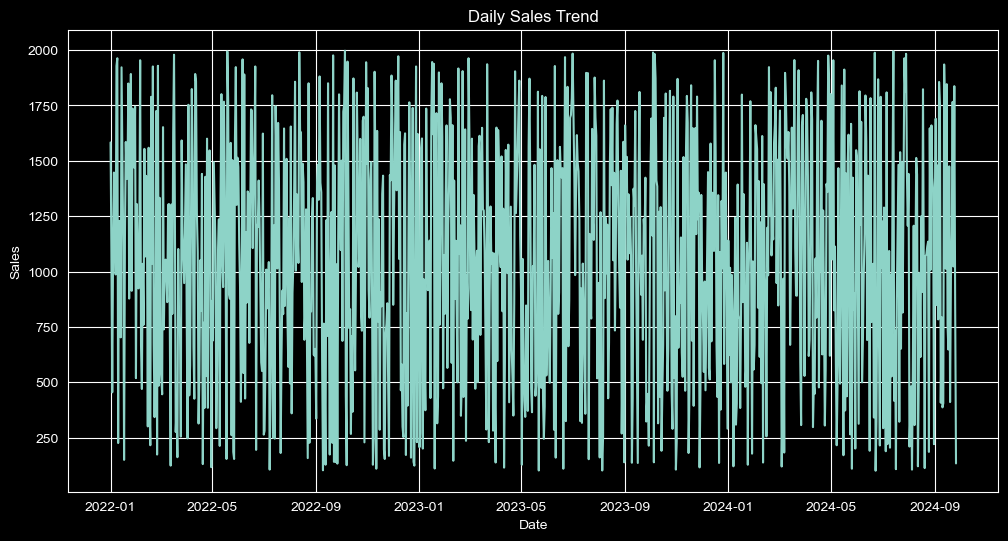

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df_grouped['date'], df_grouped['sales'])
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

In [17]:
train_size = int(len(df_grouped) * 0.8)

train = df_grouped[:train_size]
test = df_grouped[train_size:]

In [1]:
import numpy as np

df_grouped['t'] = np.arange(len(df_grouped))

train = df_grouped[:train_size]
test = df_grouped[train_size:]

NameError: name 'df_grouped' is not defined

In [19]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(train[['t']], train['sales'])

test = test.copy()
test['prediction'] = model.predict(test[['t']])

In [2]:
plt.figure(figsize=(12,6))
plt.plot(train['date'], train['sales'], label='Train')
plt.plot(test['date'], test['sales'], label='Actual Sales')
plt.plot(test['date'], test['prediction'], label='Predicted Sales')
plt.title("Demand Forecasting: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'plt' is not defined

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test['sales'], test['prediction'])
rmse = np.sqrt(mean_squared_error(test['sales'], test['prediction']))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 475.34728945627256
RMSE: 555.033060286595


In [22]:
future_days = 30
future_t = np.arange(len(df_grouped), len(df_grouped) + future_days).reshape(-1, 1)

future_pred = model.predict(future_t)

future_dates = pd.date_range(start=df_grouped['date'].max() + pd.Timedelta(days=1), periods=future_days)

future_df = pd.DataFrame({
    'date': future_dates,
    'forecasted_sales': future_pred
})

future_df.head()

C:\Users\AMAN SHARMA\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,date,forecasted_sales
0,2024-09-27,1019.169661
1,2024-09-28,1019.122677
2,2024-09-29,1019.075693
3,2024-09-30,1019.028708
4,2024-10-01,1018.981724


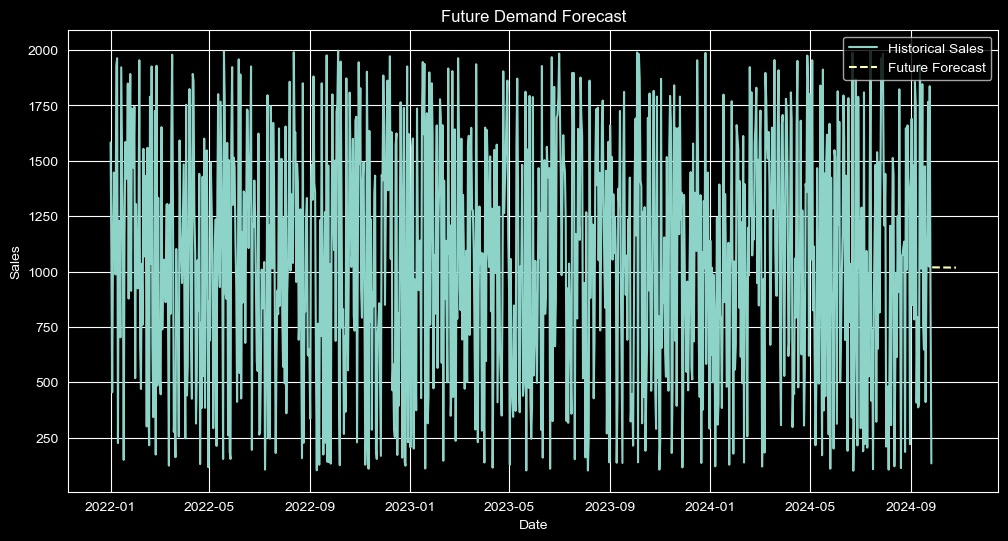

In [23]:
plt.figure(figsize=(12,6))
plt.plot(df_grouped['date'], df_grouped['sales'], label='Historical Sales')
plt.plot(future_df['date'], future_df['forecasted_sales'], label='Future Forecast', linestyle='dashed')
plt.title("Future Demand Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
import pandas as pd

# Create metrics dataframe
metrics_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE"],
    "Value": [mae, rmse]
})

# Save everything into one Excel workbook
with pd.ExcelWriter("FMCG_Dashboard_Data.xlsx", engine="openpyxl") as writer:
    df_grouped.to_excel(writer, sheet_name="sales_data", index=False)
    test[['date', 'sales', 'prediction']].to_excel(writer, sheet_name="actual_vs_predicted", index=False)
    future_df.to_excel(writer, sheet_name="future_forecast", index=False)
    metrics_df.to_excel(writer, sheet_name="metrics", index=False)

print("Excel file created successfully: FMCG_Dashboard_Data.xlsx")

Excel file created successfully: FMCG_Dashboard_Data.xlsx


In [25]:
from statsmodels.tsa.arima.model import ARIMA

# Fit model
model_arima = ARIMA(df_grouped['sales'], order=(5,1,0))
model_arima_fit = model_arima.fit()

# Forecast
forecast = model_arima_fit.forecast(steps=30)

print(forecast)

1000    1127.869098
1001    1189.725282
1002    1029.751795
1003    1028.606957
1004     892.065256
1005     878.174797
1006    1030.601607
1007    1019.076836
1008     979.020092
1009     969.134885
1010     959.741075
1011     970.700575
1012     990.042359
1013     982.729790
1014     974.666033
1015     973.880041
1016     975.079263
1017     977.862761
1018     979.439818
1019     977.385159
1020     976.209015
1021     976.535404
1022     977.094122
1023     977.468281
1024     977.409957
1025     977.006409
1026     976.916611
1027     977.061892
1028     977.170774
1029     977.183265
Name: predicted_mean, dtype: float64


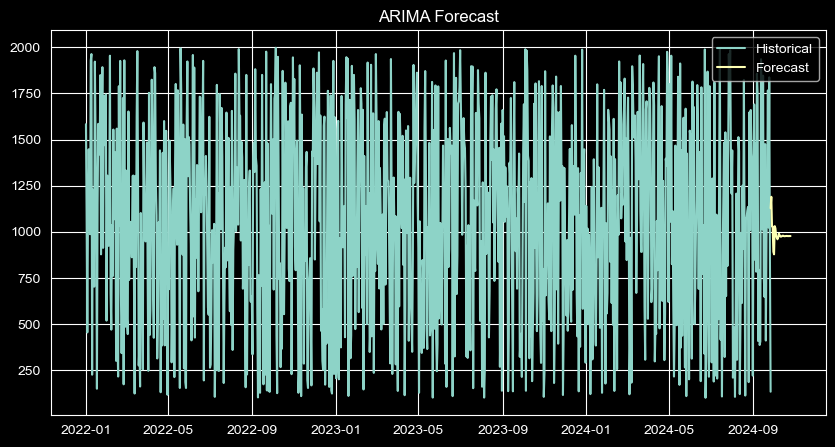

In [26]:
plt.figure(figsize=(10,5))
plt.plot(df_grouped['date'], df_grouped['sales'], label='Historical')
plt.plot(pd.date_range(df_grouped['date'].iloc[-1], periods=30, freq='D'), forecast, label='Forecast')
plt.legend()
plt.title("ARIMA Forecast")
plt.show()

In [27]:
df_grouped['month'] = df_grouped['date'].dt.month
df_grouped['day'] = df_grouped['date'].dt.day
df_grouped['weekday'] = df_grouped['date'].dt.weekday

In [28]:
from sklearn.metrics import r2_score

r2 = r2_score(test['sales'], test['prediction'])
print("R2 Score:", r2)

R2 Score: -0.002228160622122388
